 # <font color="#e6c837"> Profit Prediction Model Projesi (Regression): </font>

&nbsp;&nbsp;&nbsp; Kâr tahmini konusunda şirketler bazen senelik bazen aylık bazen de piyasaya yeni sürecekleri bir nesne adına bugünden gelecek bazlı tahmin yürütebilmenin değerini bilirler. Çünkü yapacakları yatırım buna göre şekil alır ve yanlış yatırım ile zarar etmekten kaçınmış olurlar. Bu yüzden bu projemizde kâr tahmin edebilen bir modelleme oluşturuyor olacağız. Bu planımızı geleneksel makine yöntemleri ile inceleyecek sonuçları görselleştireceğiz. Projemiz bir regresyon projesi olduğundan r2_score'u %80 üstü tutmaya çalışacağız. Tabi Root Mean Squared Error'u yani yanılma payımızı da düşük tutmaya çalışacağız.

In [1]:
# Merhaba,
# Bu ödevde verilecek cevaplarıma kullanmak adına karar kıldığım Font '#e6c837' dur.

#### **Veri Sözlüğü:** <br>
**R&D Spend: :** Ar-Ge Harcamaları<br>
**Administration:** Yönetim<br>
**Marketing Spend:** Pazarlama Harcamaları<br>
**State:** Eyalet<br>

***Hedef: "Profit" (Kâr) sütunu***

<img src='https://img.freepik.com/free-photo/green-arrow-is-going-up-stacks-coins-arranged-bar-graph_35913-3151.jpg?semt=ais_hybrid&w=740&q=80'>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

import warnings
warnings.filterwarnings('ignore')

from yellowbrick.regressor import ResidualsPlot
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

import tensorflow as tf
from sklearn.pipeline import Pipeline
import os

from joblib import dump

In [40]:
df = pd.read_csv("https://raw.githubusercontent.com/amankharwal/Website-data/master/Startups.csv")

## <font color="#e6c837"> EDA - Exploratory Data Analysis: </font>

&nbsp;&nbsp;&nbsp; Datasetimizde bir cvs dosyası içerisinde bir şirketin detay bilgilerini içeren excel dosyasından oluşuyor. Biz bunu netten çekiyoruz bu projede ve bu dosya içerisinde yer alan diğer detayları incelemek ile projemize başlayalım.

In [41]:
df.head()

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


In [42]:
df.tail()

,R&D Spend,Administration,Marketing Spend,State,Profit
45,1000.23,124153.04,1903.93,New York,64926.08
46,1315.46,115816.21,297114.46,Florida,49490.75
47,0.00,135426.92,0.00,California,42559.73
48,542.05,51743.15,0.00,New York,35673.41
49,0.00,116983.80,45173.06,California,14681.40


In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   R&D Spend        50 non-null     float64
 1   Administration   50 non-null     float64
 2   Marketing Spend  50 non-null     float64
 3   State            50 non-null     object 
 4   Profit           50 non-null     float64
dtypes: float64(4), object(1)
memory usage: 2.1+ KB


&nbsp;&nbsp;&nbsp; Bir sütunun object değerler aldığını görüyoruz yukarıdaki bilgilerde. Onu düzenliyor olacağız.

In [44]:
df.describe()

,R&D Spend,Administration,Marketing Spend,Profit
count,50.000000,50.000000,50.000000,50.000000
mean,73721.615600,121344.639600,211025.097800,112012.639200
std,45902.256482,28017.802755,122290.310726,40306.180338
min,0.000000,51283.140000,0.000000,14681.400000
25%,39936.370000,103730.875000,129300.132500,90138.902500
50%,73051.080000,122699.795000,212716.240000,107978.190000
75%,101602.800000,144842.180000,299469.085000,139765.977500
max,165349.200000,182645.560000,471784.100000,192261.830000


&nbsp;&nbsp;&nbsp;Sütunların birbirlerine göre korelasyonuna bakalım.

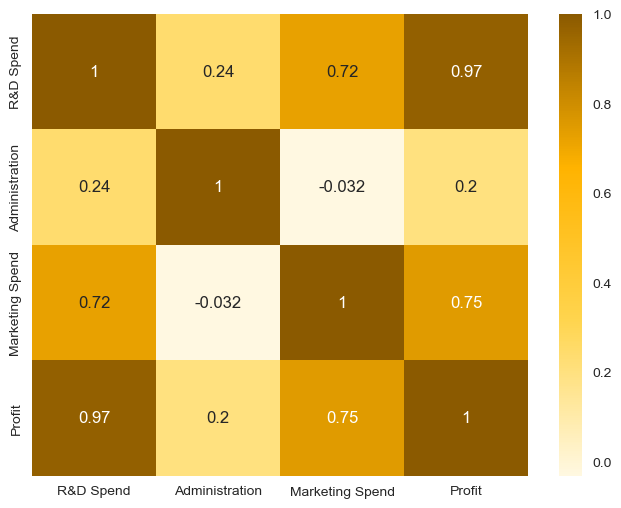

In [45]:
gold_colors = ['#fff8e1', '#ffd54f', '#ffb300', '#8b5a00']  # açıkten koyuya
gold_cmap = LinearSegmentedColormap.from_list('gold_cmap', gold_colors)

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap=gold_cmap)
plt.show()

&nbsp;&nbsp;&nbsp;Diğer sütunların hedef sütununa göre durumuna da bir bakalım.

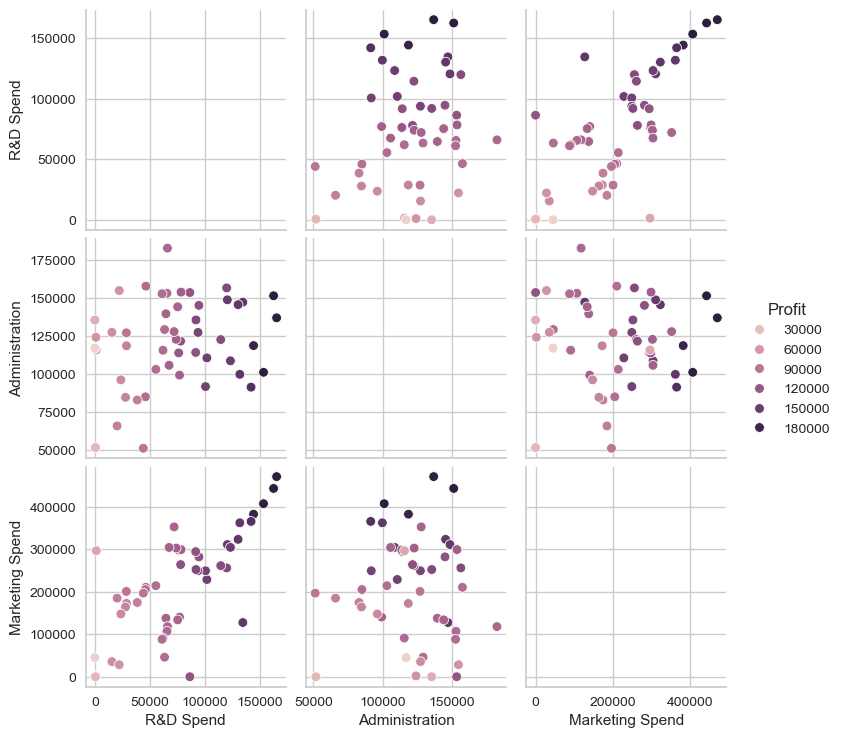

In [47]:
sns.pairplot(df,hue='Profit');

In [48]:
df.isnull().sum()

R&D Spend          0
Administration     0
Marketing Spend    0
State              0
Profit             0
dtype: int64

In [49]:
df.shape

(50, 5)

&nbsp;&nbsp;&nbsp;Veri setimizde boş değerler olmadığından dataframe'imiz halihazırda modellemeye hazır görünüyor. Fakat modellemeden önce object olan "State" sütununun içeriğine göz atıp onu 'getdummies' ile pandas'ın anlayabileceği bir hale getirelim.

## <font color="#e6c837"> Feature Engineering: </font>

&nbsp;&nbsp;&nbsp; Bu kısımda sadece yukarıda belirtilen object olayını düzenliyor olacağız. Ama önce o sütunun içeriğine bakalım.

In [50]:
df['State'].unique()

array(['New York', 'California', 'Florida'], dtype=object)

In [51]:
df = pd.get_dummies(df, columns=['State'], drop_first=True)

In [53]:
df.head()

,R&D Spend,Administration,Marketing Spend,Profit,State_Florida,State_New York
0,165349.20,136897.80,471784.10,192261.83,False,True
1,162597.70,151377.59,443898.53,191792.06,False,False
2,153441.51,101145.55,407934.54,191050.39,True,False
3,144372.41,118671.85,383199.62,182901.99,False,True
4,142107.34,91391.77,366168.42,166187.94,True,False


&nbsp;&nbsp;&nbsp; Böylelikle yapılacak değişiklikleri tamamladık. Şimdi ise modelimizi eğitip test etme aşamasına geçiyoruz.

## <font color="#e6c837"> Model and Testing: </font>

&nbsp;&nbsp;&nbsp;İlk olarak eğitim ve hedef sütunlarını ayırıyoruz.

In [54]:
x = df.drop('Profit', axis=1)
y = df[['Profit']]

In [55]:
x_train, x_test, y_train, y_test=train_test_split(x,y, test_size=.20, random_state=42)

&nbsp;&nbsp;&nbsp;Önce rastgele geleneksel bir makine öğrenme modeli olan LinearRegression ile modelimizi oluşturup test ediyor olacağız. 

In [56]:
lr=LinearRegression()

In [57]:
model=lr.fit(x_train,y_train)

In [58]:
tahmin=model.predict(x_test)

In [59]:
r2_score(y_test,tahmin)

0.8987266414328635

In [60]:
mean_squared_error(y_test,tahmin)**.5

9055.957323458473

&nbsp;&nbsp;&nbsp;Modelimizin tahmini ile gerçek kâr arasındaki farkı inceleyelim.

In [61]:
karsilastirma=pd.DataFrame()

In [62]:
karsilastirma['gercekfiyat']=y_test
karsilastirma['tahmin']=tahmin

In [63]:
karsilastirma

,gercekfiyat,tahmin
13,134307.35,126362.879083
39,81005.76,84608.453836
30,99937.59,99677.494251
45,64926.08,46357.460686
17,125370.37,128750.482885
48,35673.41,50912.417419
26,105733.54,109741.350327
25,107404.34,100643.242816
32,97427.84,97599.275746
19,122776.86,113097.425244


In [64]:
residuals=y_test-tahmin 

In [65]:
residuals

,Profit
13,7944.470917
39,-3602.693836
30,260.095749
45,18568.619314
17,-3380.112885
48,-15239.007419
26,-4007.810327
25,6761.097184
32,-171.435746
19,9679.434756


&nbsp;&nbsp;&nbsp;Sonucumuzu görselleştirelim.

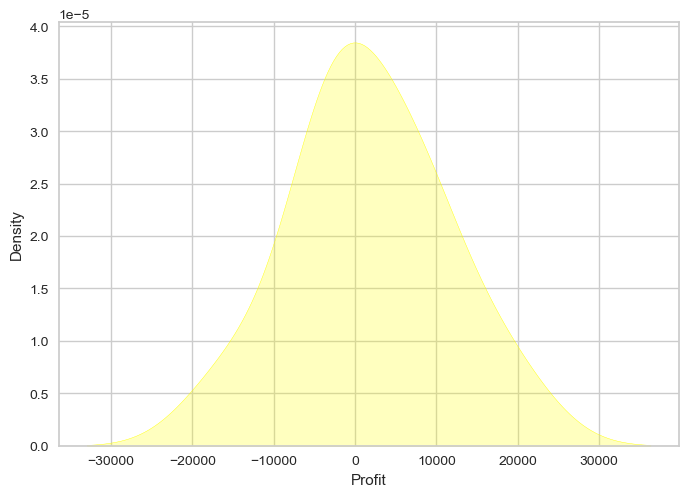

In [66]:
sns.kdeplot(x=residuals['Profit'], fill=True, color='yellow');

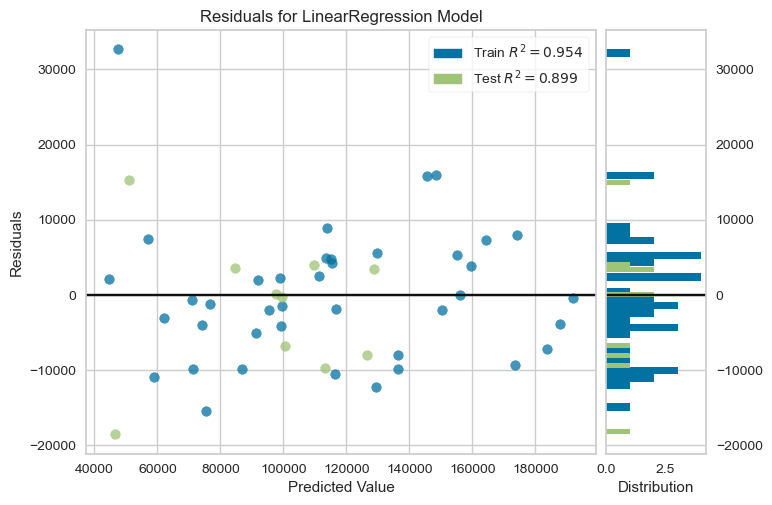

In [67]:
vis=ResidualsPlot(lr)
vis.fit(x_train,y_train)
vis.score(x_test,y_test)
vis.show()
plt.show()

&nbsp;&nbsp;&nbsp; Görüldüğü üzere 'LinearRegression' yöntemi ile sonucumuz yani tahmin oranımız r2_score'a bakılırsa 0.8987 gibi bir değer ile yani %89 gibi bir oranda doğruluk yansıtıyor. Diğer yandan hata payımız yani RMSE: 9055.957 gibi bir değer geliyor yani yüksek bir hata payı bizim için bu ve sanırım sebebi satır sayımızın azlığı diye düşünüyoruz. Fakat modelimiz eğitim datasını iyi öğrenmiş durumda. Peki bizim projemiz için ideal makine öğrenimi nedir, buna bakalım.

In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns",100)

from sklearn.linear_model import LinearRegression,SGDRegressor,Ridge,Lasso,ElasticNet
from sklearn.neighbors import KNeighborsRegressor, RadiusNeighborsRegressor
from sklearn.ensemble import GradientBoostingRegressor,AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor, plot_tree, ExtraTreeRegressor
#pip install xgboost
from xgboost import XGBRegressor
from sklearn.svm import SVR

from sklearn.neural_network import MLPRegressor

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

def algo_test(x,y):
        #Bütün modelleri tanımlıyorum
        L=LinearRegression()
        R=Ridge()
        Lass=Lasso()
        E=ElasticNet()
        sgd=SGDRegressor()
        ETR=ExtraTreeRegressor()
        GBR=GradientBoostingRegressor()
        kn=KNeighborsRegressor()
        rkn=RadiusNeighborsRegressor(radius=1.0)
        ada=AdaBoostRegressor()
        dt=DecisionTreeRegressor()
        xgb=XGBRegressor()
        svr=SVR()
        mlp_regressor = MLPRegressor()

       
        
        algos=[L,R,Lass,E,sgd,ETR,GBR,ada,kn,dt,xgb,svr,mlp_regressor]
        algo_names=['Linear','Ridge','Lasso','ElasticNet','SGD','Extra Tree','Gradient Boosting',
                    'KNeighborsRegressor','AdaBoost','Decision Tree','XGBRegressor','SVR','mlp_regressor']
        x=MinMaxScaler().fit_transform(x)
        x_train, x_test, y_train, y_test=train_test_split(x,y,test_size=.20,random_state=42)
        
        r_squared= []
        rmse= []
        mae= []
        
        #Hata ve doğruluk oranlarını bir tablo haline getirmek için bir dataframe oluşturuyorum
        result=pd.DataFrame(columns=['R_Squared','RMSE','MAE'],index=algo_names)
        
        
        for algo in algos:
            p=algo.fit(x_train,y_train).predict(x_test)
            r_squared.append(r2_score(y_test,p))
            rmse.append(mean_squared_error(y_test,p)**.5)
            mae.append(mean_absolute_error(y_test,p))
        
            

        #result adlı tabloya doğruluk ve hata oranlarımı yerleştiriyorum
        result.R_Squared=r_squared
        result.RMSE=rmse
        result.MAE=mae
        
       #oluşturduğum result tablosunu doğruluk oranına (r2_score) göre sıralayıp dönüyor
        rtable=result.sort_values('R_Squared',ascending=False)
        return rtable

In [69]:
algo_test(x,y)

,R_Squared,RMSE,MAE
Gradient Boosting,0.918707,8113.572011,7725.085231
Lasso,0.898821,9051.721413,6959.083728
Linear,0.898727,9055.957323,6961.477813
KNeighborsRegressor,0.885849,9614.496215,8027.543939
XGBRegressor,0.882800,9742.042086,7506.699219
Extra Tree,0.879965,9859.172930,7711.430000
Ridge,0.862078,10568.253511,8760.011839
Decision Tree,0.853620,10887.479250,8437.984000
SGD,0.828146,11796.863680,9464.139320
AdaBoost,0.135888,26452.815178,21211.102000


&nbsp;&nbsp;&nbsp;En iyi sonuç veren test 'Gradient Boosting' geleneksel makine modellemesi imiş. Öyleyse ona yakından bakalım. 

In [70]:
GBR=GradientBoostingRegressor()

In [71]:
model2=GBR.fit(x_train,y_train)

In [72]:
tahmin2=model2.predict(x_test)

In [73]:
r2_score(y_test,tahmin2)

0.913155768614951

In [74]:
mean_squared_error(y_test,tahmin2)**.5

8386.04616144501

&nbsp;&nbsp;&nbsp; Yeni modelimizin yaptığı tahmin ve gerçek değerler arasındaki farka da bakalım. 

In [75]:
karsilastirma2=pd.DataFrame()

In [76]:
karsilastirma2['gercekfiyat']=y_test
karsilastirma2['tahmin']=tahmin2

In [77]:
karsilastirma2

,gercekfiyat,tahmin
13,134307.35,126784.218593
39,81005.76,86795.807103
30,99937.59,95182.735950
45,64926.08,54428.498750
17,125370.37,134467.469187
48,35673.41,34224.224790
26,105733.54,115989.415335
25,107404.34,101988.947964
32,97427.84,86595.140732
19,122776.86,110792.973868


&nbsp;&nbsp;&nbsp;R2_score'u görselleştirelim.

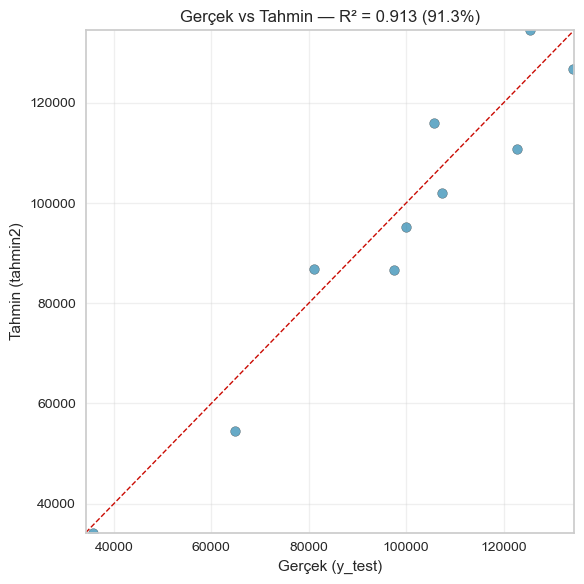

In [80]:
# y_test ve tahmin2 uyumlu hale getirme (örneğin tahmin2 (n,1) ise squeeze)
y_true = np.asarray(y_test).ravel()
y_pred = np.asarray(tahmin2).ravel()

r2 = r2_score(y_true, y_pred)
r2_pct = r2 * 100

plt.figure(figsize=(6,6))
plt.scatter(y_true, y_pred, alpha=0.6, edgecolor='k')
# 45 derece referans çizgisi (mükemmel tahmin)
lims = [min(min(y_true), min(y_pred)), max(max(y_true), max(y_pred))]
plt.plot(lims, lims, 'r--', linewidth=1)
plt.xlim(lims)
plt.ylim(lims)
plt.xlabel('Gerçek (y_test)')
plt.ylabel('Tahmin (tahmin2)')
plt.title(f'Gerçek vs Tahmin — R² = {r2:.3f} ({r2_pct:.1f}%)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

&nbsp;&nbsp;&nbsp;Tahmin oranımız ideal eğitimden sonra r2_score'a bakarsak; modelimiz kâr miktarı tahminlerinde 0.9131 gibi bir oranda yani %91 gibi bir doğruluk oranıyla tahmin edebiliyor. Hata payımız yani RMSE: 8386.04 gibi bir değer geliyor. Bu iyi değil RMS için fakat bunun sebebi satır sayısı azlığından olduğunu düşünüyoruz ve bir case study gibi çalışma olduğundan daha büyük bir veri setinde modelin daha verimli sonuçlar verebileceğini öngörüyoruz. Şimdi modelimizi kaydedelim.

In [83]:
dump(model2, 'profit_prediction_model.joblib')

['profit_prediction_model.joblib']

**Conclusion:** &nbsp;&nbsp;Sonuç olarak; Bu projede önce yapılan LinearRegression geleneksel makine öğrenme testi ve daha sonrasında yapılan bu verisetine göre ideal model olduğu görülen 'Gradient Boosting' model testi kâr oranlarını rakamsal olarak tahmin edebilmesi açısından %91 gibi bir oranla doğru tahminler veriyor. En iyi modelle yani %91 doğruluk oranı ile modelimiz 'profit_prediction_model.joblib' dosyası olarak kaydedilmiştir.<br>
&nbsp;&nbsp;&nbsp; Kârı önceden bilmek isteyen büyük şirketler bu model rahatlıkla kullanılabilir ve buna binaen maliyet hesaplarını kolaylıkla oluşturabilirler. 

Ve kapanış..